In [10]:
###Merge all cleaned datasets

import pandas as pd
import glob
import os

# 1. Get all paths
path = "../data/cleaned_data/"
clean_files = glob.glob(os.path.join(path, "*_clean.csv"))

print(f"Files found by glob: {[os.path.basename(f) for f in clean_files]}")

all_dfs = []

for file_path in clean_files:
    df_temp = pd.read_csv(file_path)
    
    file_name = os.path.basename(file_path)
    country_from_file = file_name.split('_')[0].capitalize() 
    
    df_temp['Country'] = country_from_file
    all_dfs.append(df_temp)
    print(f"Loaded {country_from_file} successfully.")

# 2. Final Merge
master_df = pd.concat(all_dfs, ignore_index=True)
master_df['Date'] = pd.to_datetime(master_df['Date'])

print(f"\nFinal Master List: {master_df['Country'].unique()}")

Files found by glob: ['kenya_clean.csv', 'tanzania_clean.csv', 'nigeria_clean.csv', 'sudan_clean.csv', 'ethiopia_clean.csv', 'Sudan_clean.csv']
Loaded Kenya successfully.
Loaded Tanzania successfully.
Loaded Nigeria successfully.
Loaded Sudan successfully.
Loaded Ethiopia successfully.
Loaded Sudan successfully.

Final Master List: <ArrowStringArray>
['Kenya', 'Tanzania', 'Nigeria', 'Sudan', 'Ethiopia']
Length: 5, dtype: str


<>:14: SyntaxWarning: invalid escape sequence '\c'
<>:14: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_168426/647967687.py:14: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel("Temperature ($^{\circ}C$)") # Using LaTeX for units [cite: 11]


<Figure size 1400x700 with 0 Axes>

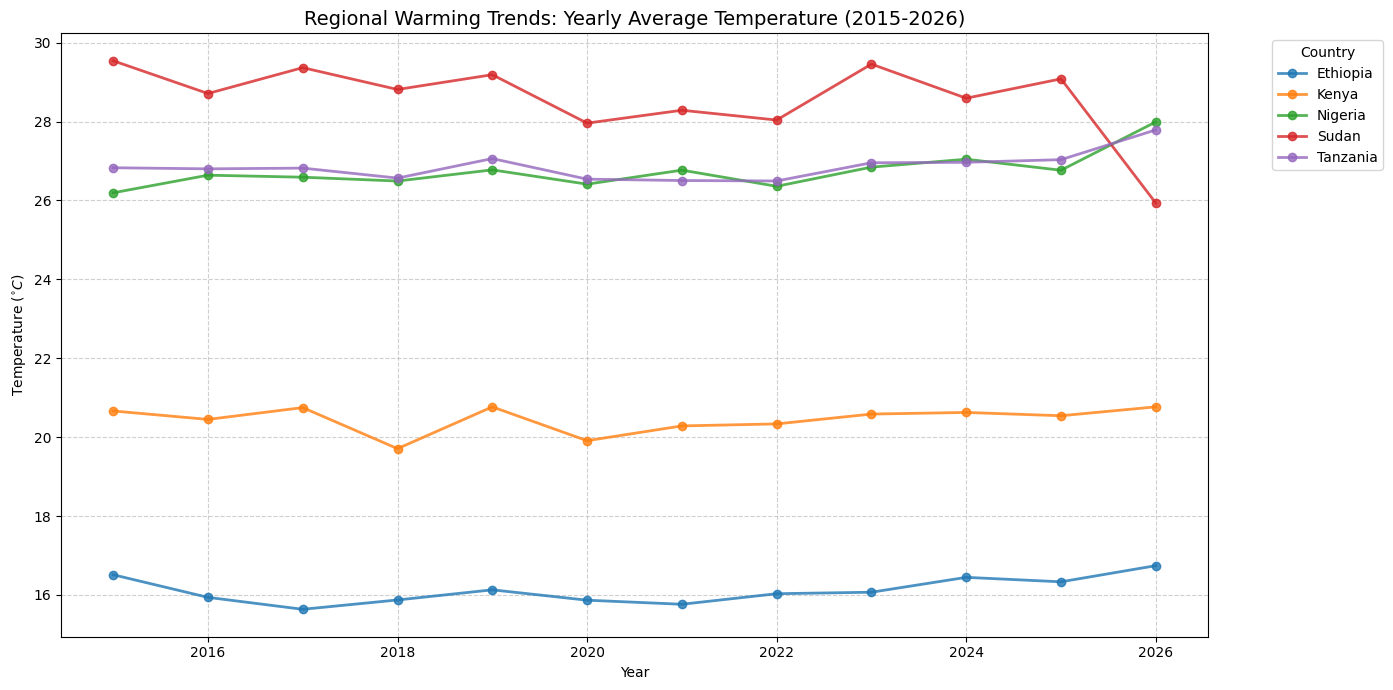

In [11]:
###comparative temeperature trends


import matplotlib.pyplot as plt
import seaborn as sns

# 1. Yearly Temperature Trend Comparison
plt.figure(figsize=(14, 7))
# Use 'YE' for Year End frequency in newer Pandas versions
yearly_temp = master_df.groupby(['Country', master_df['Date'].dt.year])['T2M'].mean().unstack(level=0)

yearly_temp.plot(marker='o', linewidth=2, alpha=0.8, figsize=(14, 7))
plt.title("Regional Warming Trends: Yearly Average Temperature (2015-2026)", fontsize=14)
plt.ylabel("Temperature ($^{\circ}C$)") # Using LaTeX for units [cite: 11]
plt.xlabel("Year")
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

<>:9: SyntaxWarning: invalid escape sequence '\_'
<>:9: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_168426/4089527424.py:9: SyntaxWarning: invalid escape sequence '\_'
  plt.title("Frequency of Extreme Heat Events ($T2M\_MAX > 35^{\circ}C$)", fontsize=13)
/tmp/ipykernel_168426/4089527424.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=heat_days.index, y=heat_days.values, palette='Reds_r')


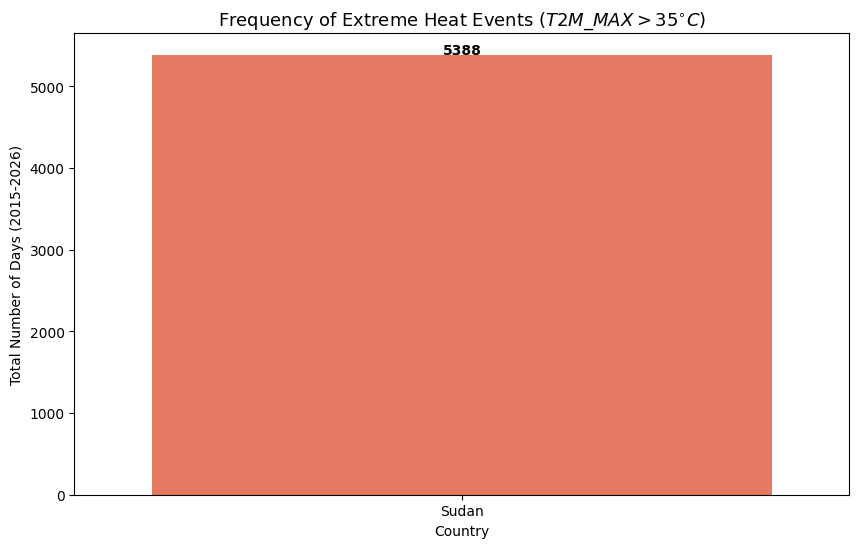

In [12]:
###Extreme weather analysis ( the risk factor)

# 2. Heat Stress Days (>35°C) per Country
# We filter the master_df for extreme heat events
heat_days = master_df[master_df['T2M_MAX'] > 35].groupby('Country').size().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=heat_days.index, y=heat_days.values, palette='Reds_r')
plt.title("Frequency of Extreme Heat Events ($T2M\_MAX > 35^{\circ}C$)", fontsize=13)
plt.ylabel("Total Number of Days (2015-2026)")
plt.xlabel("Country")
for i, v in enumerate(heat_days.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.show()

/tmp/ipykernel_168426/2645960508.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=master_df, x='Country', y='PRECTOTCORR', palette='Blues', showfliers=False)


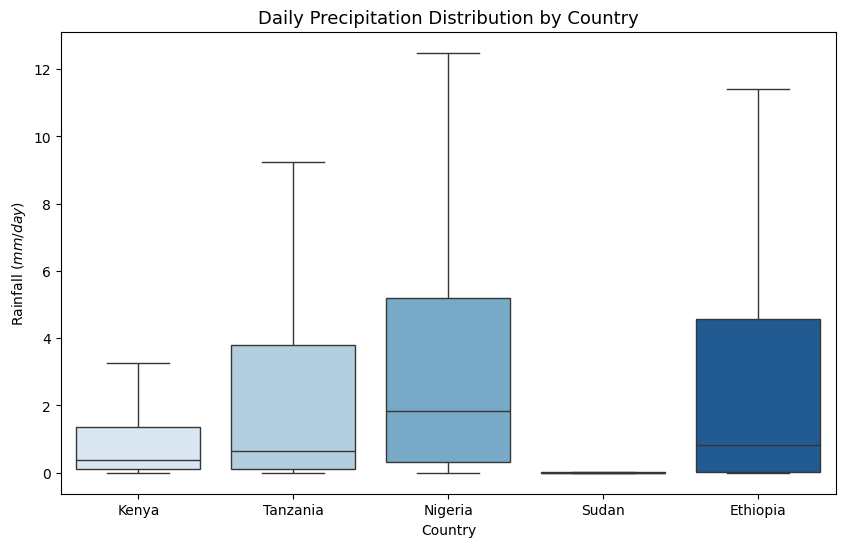

In [13]:
###precipitaion variability

# 3. Rainfall Variability (Standard Deviation)
rain_stats = master_df.groupby('Country')['PRECTOTCORR'].agg(['mean', 'std']).sort_values(by='std', ascending=False)

plt.figure(figsize=(10, 6))
sns.boxplot(data=master_df, x='Country', y='PRECTOTCORR', palette='Blues', showfliers=False)
plt.title("Daily Precipitation Distribution by Country", fontsize=13)
plt.ylabel("Rainfall ($mm/day$)") # Using LaTeX for units [cite: 20]
plt.show()

In [16]:
###final vulnerability ranking

# Final Ranking Logic
vulnerability_report = master_df.groupby('Country').agg({
    'T2M': 'mean',              # Average Heat
    'T2M_MAX': 'max',           # Peak Heat
    'PRECTOTCORR': 'std'        # Rain Unpredictability
}).rename(columns={
    'T2M': 'Avg_Temp',
    'T2M_MAX': 'Record_High',
    'PRECTOTCORR': 'Rain_Volatility'
})

# Normalize and create a simple score (higher = more vulnerable)
vulnerability_report['Vulnerability_Score'] = (
    (vulnerability_report['Avg_Temp'] / vulnerability_report['Avg_Temp'].max()) + 
    (vulnerability_report['Rain_Volatility'] / vulnerability_report['Rain_Volatility'].max())
).round(2)

print("--- COP32 OFFICIAL VULNERABILITY RANKING ---")
print(vulnerability_report.sort_values(by='Vulnerability_Score', ascending=False))

--- COP32 OFFICIAL VULNERABILITY RANKING ---
           Avg_Temp  Record_High  Rain_Volatility  Vulnerability_Score
Country                                                               
Tanzania  26.802422        33.93         8.003947                 1.93
Nigeria   26.656928        32.88         7.266742                 1.83
Sudan     28.759007        45.96         3.057486                 1.38
Ethiopia  16.068500        30.93         6.289061                 1.34
Kenya     20.427600        34.27         3.180228                 1.11


In [15]:
# Save the final merged dataset for the Streamlit app

output_path = '../data/master_climate_data.csv'

master_df.to_csv(output_path, index=False)

print(f"✅ Success! Master data saved to {output_path}")
print(f"Total rows: {len(master_df)}")
print(f"Countries included: {master_df['Country'].unique()}")



✅ Success! Master data saved to ../data/master_climate_data.csv
Total rows: 24648
Countries included: <ArrowStringArray>
['Kenya', 'Tanzania', 'Nigeria', 'Sudan', 'Ethiopia']
Length: 5, dtype: str
